In [14]:
# ======================================================
# Boosted Trees on Fruit Disease Dataset
# ======================================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from tqdm import tqdm

In [16]:
# ======================================================
# Paths
# ======================================================
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"
IMAGE_SIZE = (128, 128)

# ======================================================
# Load Training Dataset
# ======================================================
X, y = [], []
print("📦 Loading training dataset...")
for label in tqdm(os.listdir(TRAIN_DIR)):
    label_path = os.path.join(TRAIN_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X.append(img_array)
            y.append(label)
        except:
            pass

X = np.array(X, dtype="float32") / 255.0
y = np.array(y)
print(f"✅ Loaded {len(X)} images from {len(np.unique(y))} classes.")


📦 Loading training dataset...


100%|██████████| 21/21 [02:48<00:00,  8.03s/it]


✅ Loaded 6399 images from 21 classes.


In [18]:
# ======================================================
# Train-Validation Split
# ======================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# ======================================================
# Flatten for tree input
# ======================================================
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)

# Standardize features
scaler = StandardScaler()
X_train_flat = scaler.fit_transform(X_train_flat)
X_val_flat = scaler.transform(X_val_flat)

In [7]:
# ======================================================
# Train Boosted Tree Classifier
# ======================================================
print("\n🚀 Training Boosted Trees (Gradient Boosting)...")
boosted_tree = GradientBoostingClassifier(
    n_estimators=5,      # number of boosting stages
    learning_rate=0.1,     # step size
    max_depth=3,           # depth of each tree
    random_state=42
)
boosted_tree.fit(X_train_flat, y_train_enc)


🚀 Training Boosted Trees (Gradient Boosting)...


GradientBoostingClassifier(n_estimators=5, random_state=42)

In [8]:
# ======================================================
# Evaluate on Validation
# ======================================================
y_pred_val = boosted_tree.predict(X_val_flat)
print("\n✅ Validation Results:")
print("Accuracy:", accuracy_score(y_val_enc, y_pred_val))
print("\nClassification Report:")
print(classification_report(y_val_enc, y_pred_val, target_names=label_encoder.classes_))


✅ Validation Results:
Accuracy: 0.6640625

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.55      0.92      0.69       198
                         Grape__black_rot       0.60      0.63      0.61       142
                           Grape__healthy       0.79      0.32      0.46        68
Grape__leaf_blight_(isariopsis_leaf_spot)       0.70      0.71      0.71       128
                          Lemon__diseased       0.45      0.50      0.48        10
                           Lemon__healthy       0.58      0.68      0.62        22
                    Pomegranate__diseased       0.81      0.76      0.78        38
                     Pomegranate__healthy       0.74      0.78      0.76        40
                       guava_Disease Free       0.27      0.17      0.21        18
                        guava_Phytopthora       0.33      0.12      0.18        16
                   

In [9]:
# ======================================================
# Load Test Dataset
# ======================================================
X_test, y_test = [], []
print("\n📦 Loading test dataset...")
for label in tqdm(os.listdir(TEST_DIR)):
    label_path = os.path.join(TEST_DIR, label)
    if not os.path.isdir(label_path):
        continue
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        try:
            img = load_img(img_path, target_size=IMAGE_SIZE)
            img_array = img_to_array(img)
            X_test.append(img_array)
            y_test.append(label)
        except:
            pass

X_test = np.array(X_test, dtype="float32") / 255.0
y_test = np.array(y_test)

X_test_flat = X_test.reshape(len(X_test), -1)
X_test_flat = scaler.transform(X_test_flat)
y_test_enc = label_encoder.transform(y_test)


📦 Loading test dataset...


100%|██████████| 21/21 [03:08<00:00,  8.96s/it]


In [10]:
# ======================================================
# Predict on Test Data
# ======================================================
y_pred_test = boosted_tree.predict(X_test_flat)

In [11]:
# ======================================================
# Evaluation Metrics
# ======================================================
acc = accuracy_score(y_test_enc, y_pred_test)
precision, recall, f1, _ = precision_recall_fscore_support(y_test_enc, y_pred_test, average='weighted')

print("\n🎯 Test Results (Boosted Trees):")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_enc, y_pred_test, target_names=label_encoder.classes_))



🎯 Test Results (Boosted Trees):
Accuracy: 0.6282
Precision: 0.6495
Recall: 0.6282
F1 Score: 0.6217

Classification Report:
                                           precision    recall  f1-score   support

                     Grape__black_measles       0.52      0.88      0.65       277
                         Grape__black_rot       0.59      0.60      0.60       200
                           Grape__healthy       0.87      0.35      0.50        94
Grape__leaf_blight_(isariopsis_leaf_spot)       0.64      0.68      0.66       178
                          Lemon__diseased       0.58      0.44      0.50        16
                           Lemon__healthy       0.79      0.47      0.59        32
                    Pomegranate__diseased       0.89      0.87      0.88        55
                     Pomegranate__healthy       0.83      0.86      0.85        58
                       guava_Disease Free       0.36      0.19      0.25        26
                        guava_Phytopthora    

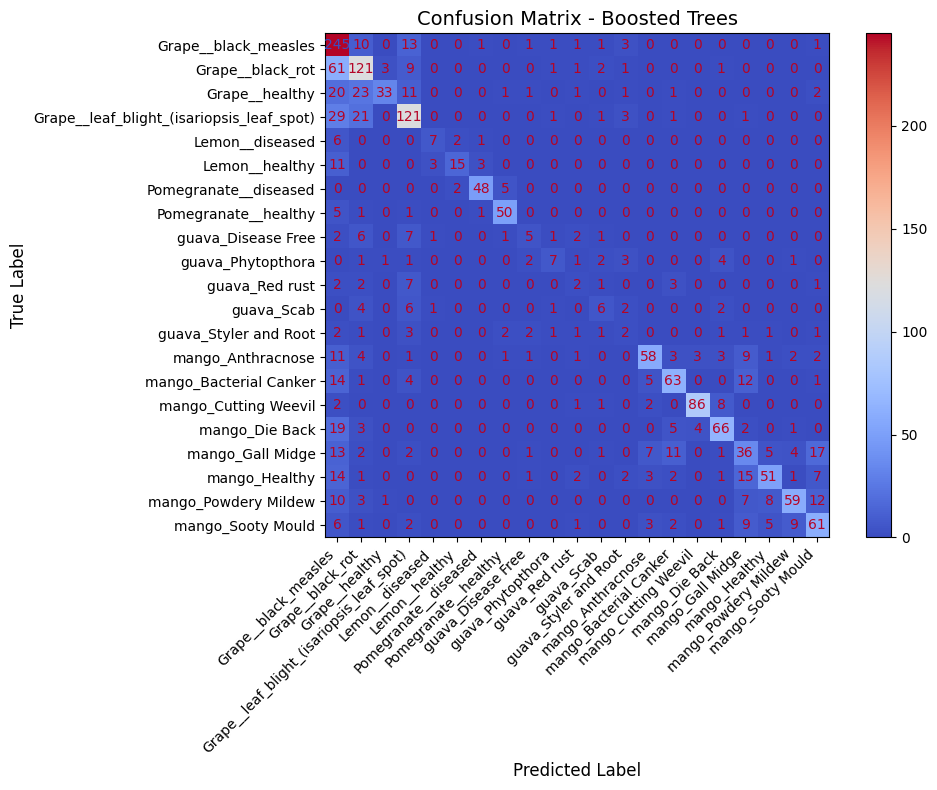

In [12]:
cm = confusion_matrix(y_test_enc, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

fig, ax = plt.subplots(figsize=(max(8, len(label_encoder.classes_) * 0.5), 8))
disp.plot(cmap="coolwarm", ax=ax, colorbar=True)

plt.title("Confusion Matrix - Boosted Trees", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


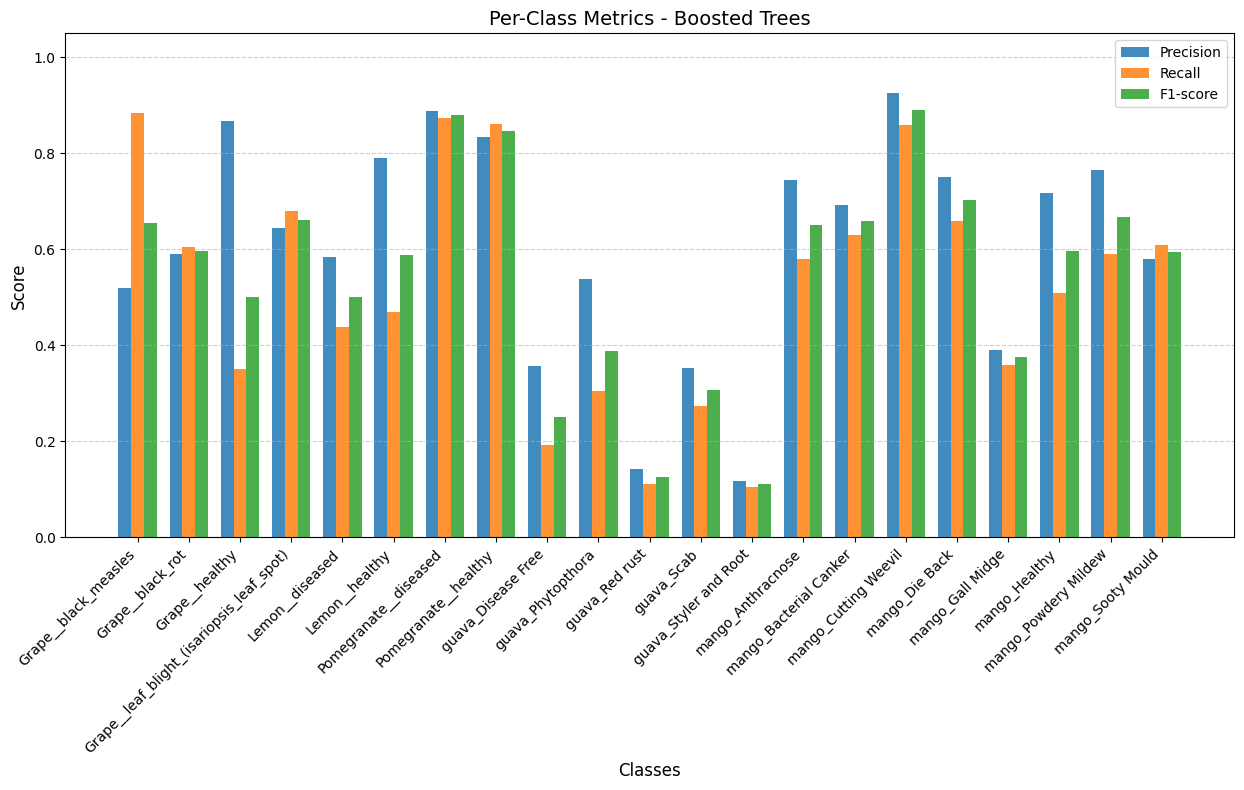

In [13]:
from sklearn.metrics import precision_recall_fscore_support
import matplotlib.pyplot as plt
import numpy as np

# Compute per-class metrics safely
precisions, recalls, f1s, _ = precision_recall_fscore_support(
    y_test_enc, y_pred_test, zero_division=0
)

x = np.arange(len(label_encoder.classes_))
bar_width = 0.25

plt.figure(figsize=(max(10, len(label_encoder.classes_) * 0.6), 8))

plt.bar(x - bar_width, precisions, width=bar_width, label='Precision', alpha=0.85)
plt.bar(x, recalls, width=bar_width, label='Recall', alpha=0.85)
plt.bar(x + bar_width, f1s, width=bar_width, label='F1-score', alpha=0.85)

plt.xticks(x, label_encoder.classes_, rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(0, 1.05)
plt.title("Per-Class Metrics - Boosted Trees", fontsize=14)
plt.xlabel("Classes", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
